# Figures S5 and S6 — *Catenibacterium*

| Output | Content |
| --- | --- |
| **Figure S5a** | Per-study prevalence of SGB6783 and SGB6778 in Westernized vs non-Westernized samples |
| **Figure S5b** | Fold change in relative abundance between lifestyles, carriers only, from a linear mixed model |
| **Figure S5c, S5d** | ANI within and between lifestyles |
| **Figure S5e** | Phylogeny of *Catenibacterium* MAGs and isolates (GraPhlAn annotation) |
| **Figure S6** | Glycan utilisation of three *Catenibacterium* strains |

Two SGBs are compared throughout: **SGB6778_group** is *C. mitsuokai* and **SGB6783** is *C. tridentinum*.

Note that panels a and b use the **vJan25** MetaPhlAn profiles, not the vJan21 profiles behind Figures 1 and 2. The SGB identifiers are not interchangeable between the two releases.

## 0. Setup

The analyses in this notebook ran from two different working directories, so paths are given as absolute roots rather than relative ones. `CACHE_ABUNDANCE` stores the per-sample abundances extracted from ~6,900 profile files; delete it to re-read them.

In [38]:
import os
import glob

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats as sps
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
from Bio import Phylo


METADATA = '../data/ancient_adults_metadata_filtered.tsv'
PROFILE_RELEASE = ('metaphlan-4', 'vJan25')          # directory name must contain both
CACHE_ABUNDANCE = '../data/cache_catenibacterium_abundance.tsv'

TREE_DIR = '../data/cate_tree'
MAG_TABLE = '../data/MAG_table_filtered.tsv'
MAG_METADATA = '../data/catenibacterium_mags_meta_full.tsv'
ANNOTATION_OUT = '../data/cate_phylo_annot_rerooted_longest_internal.txt'

GLYCAN_DIR = '../data/'

MITSUOKAI = 'Catenibacterium mitsuokai (SGB6778_group)'
TRIDENTINUM = 'Catenibacterium tridentinum (SGB6783)'
CATENIBACTERIUM = [TRIDENTINUM, MITSUOKAI]           # panel order: SGB6783 first

LIFESTYLE_COLORS = {'no': '#397797', 'yes': '#d5d53e'}
LIFESTYLE_LABELS = {'no': 'W', 'yes': 'NW'}
ALPHA = 0.05

sns.set_theme(context='paper', style='white', font='DejaVu Sans')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12,
    'axes.linewidth': 1, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'legend.frameon': False,
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

## 1. Sample metadata and *Catenibacterium* abundances

Each sample's profile is read, restricted to SGB-level rows and renormalised to 100% across those rows, exactly as in the original. Only the two *Catenibacterium* columns are kept, so the cache stays small; `total_sgb_abundance` is retained as a record of what the normalisation divided by.

In [18]:
metadata = pd.read_table(METADATA)
metadata = metadata[metadata['non_westernized'] != 'ancient']
metadata = metadata.drop(columns=[c for c in ['sample_id.1'] if c in metadata.columns])
metadata = metadata.set_index('sample_id')

metadata['non_westernized'].value_counts()

no     5661
yes    1202
Name: non_westernized, dtype: int64

In [19]:
abundances = pd.read_table("../data/cate_abundances.tsv", index_col=0)
abundances.head()

,total_sgb_abundance,Catenibacterium tridentinum (SGB6783),Catenibacterium mitsuokai (SGB6778_group),non_westernized
O2_UC49_0,99.99995,0.000000,0.0,no
O2_UC49_2,100.00004,0.000000,0.0,no
O2_UC50_0,100.00006,1.359349,0.0,no
O2_UC50_2,99.99997,2.481611,0.0,no
O2_UC51_0,99.99998,0.000000,0.0,no


How many samples carry each species, by lifestyle. "Either" counts samples carrying at least one of the two.

In [20]:
carriers = {name: abundances.loc[abundances[sgb] > 0, 'non_westernized'].value_counts()
            for name, sgb in [('C. tridentinum (SGB6783)', TRIDENTINUM),
                              ('C. mitsuokai (SGB6778_group)', MITSUOKAI)]}
either = abundances[(abundances[CATENIBACTERIUM] > 0).any(axis=1)]
carriers['Either'] = either['non_westernized'].value_counts()

pd.DataFrame(carriers).rename(index=LIFESTYLE_LABELS).T

,W,NW
C. tridentinum (SGB6783),681,467
C. mitsuokai (SGB6778_group),238,499
Either,807,645


## 2. Figure S5a — prevalence by study

Prevalence is the fraction of carriers within each study, so every point is one study, and the two lifestyles are compared with a Mann-Whitney U test over those per-study values.

In [5]:
presence = (abundances[CATENIBACTERIUM] > 0).astype(int)
presence['study_name'] = metadata['study_name']
presence['non_westernized'] = metadata['non_westernized']
prevalence_by_study = presence.groupby(['study_name', 'non_westernized'], observed=True).mean().reset_index()

n_studies = prevalence_by_study['non_westernized'].value_counts().rename(LIFESTYLE_LABELS)
print(f'studies per lifestyle: {dict(n_studies)}')


def compare_lifestyles(frame, column):
    nw = frame.loc[frame['non_westernized'] == 'yes', column]
    w = frame.loc[frame['non_westernized'] == 'no', column]
    return mannwhitneyu(nw, w).pvalue


p_prevalence = {sgb: compare_lifestyles(prevalence_by_study, sgb) for sgb in CATENIBACTERIUM}

# Two alternative tests on the sample level, for comparison with the published annotation.
p_sample_presence = {sgb: compare_lifestyles(abundances.assign(**{sgb: presence[sgb]}), sgb)
                     for sgb in CATENIBACTERIUM}
p_sample_abundance = {sgb: compare_lifestyles(abundances[abundances[sgb] > 0], sgb)
                      for sgb in CATENIBACTERIUM}

pd.DataFrame({
    'per-study prevalence (plotted)': p_prevalence,
    'per-sample presence/absence': p_sample_presence,
    'per-sample abundance, carriers': p_sample_abundance,
}).rename(index={TRIDENTINUM: 'SGB6783', MITSUOKAI: 'SGB6778'}).T

studies per lifestyle: {'W': 41, 'NW': 18}


,SGB6783,SGB6778
per-study prevalence (plotted),6.601280e-06,3.065674e-09
per-sample presence/absence,5.895238e-130,0.000000e+00
"per-sample abundance, carriers",4.215399e-22,7.552345e-14


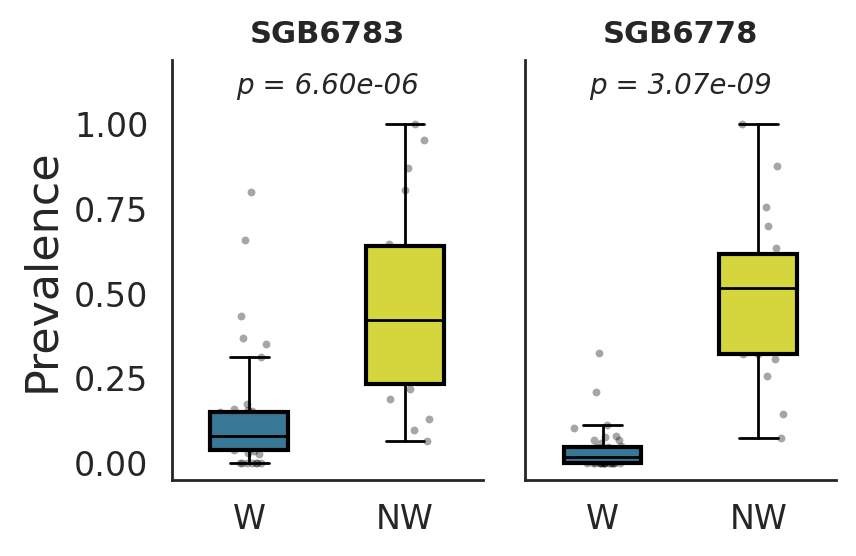

In [6]:
def lifestyle_panel(ax, frame, column, title, p_value, ylabel, log_scale=False):
    """Box plot of one column split by lifestyle, with jittered points and a p-value."""
    groups = [frame.loc[frame['non_westernized'] == key, column] for key in ('no', 'yes')]
    box = ax.boxplot(groups, positions=[0, 1], widths=0.5, patch_artist=True, showfliers=False)
    for patch, key in zip(box['boxes'], ('no', 'yes')):
        patch.set_facecolor(LIFESTYLE_COLORS[key])
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    for element in ('whiskers', 'caps', 'medians'):
        for line in box[element]:
            line.set_color('black')
            line.set_linewidth(1)

    rng = np.random.default_rng(0)
    for position, values in zip((0, 1), groups):
        ax.scatter(rng.normal(position, 0.08, len(values)), values,
                   s=8, color='black', alpha=0.35, linewidths=0)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['W', 'NW'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    if log_scale:
        ax.set_yscale('log')
    ax.text(0.5, 0.97, f'p = {p_value:.2e}', transform=ax.transAxes,
            ha='center', va='top', fontsize=10, style='italic')


fig, axes = plt.subplots(1, 2, figsize=(4.5, 3), sharey=True, dpi=200)
for ax, sgb in zip(axes, CATENIBACTERIUM):
    lifestyle_panel(ax, prevalence_by_study, sgb, sgb.split('(')[1].rstrip(')').replace('_group', ''),
                    p_prevalence[sgb], 'Prevalence')
axes[0].set_ylim(-0.05, 1.19)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Figure S5b — abundance in carriers

A linear mixed model of log abundance against lifestyle, fitted only on samples that carry the species so that the many zeros cannot drive the result. Study is a random intercept; age, gender, sequencing depth and DNA extraction kit are fixed effects. The lifestyle coefficient is reported as a fold change, non-Westernized relative to Westernized.

In [7]:
def abundance_in_carriers(frame, column, covariates=('age', 'gender', 'number_reads',
                                                     'DNA_extraction_kit', 'study_name')):
    """Mixed model of log abundance against lifestyle, on carriers only."""
    data = frame.loc[frame[column] > 0, [column, 'non_westernized', *covariates]].copy()
    for categorical in ('gender', 'DNA_extraction_kit', 'study_name', 'non_westernized'):
        data[categorical] = data[categorical].astype(str).replace({'nan': 'Unknown', 'NaN': 'Unknown'})
    data = data.dropna()
    data['log_abundance'] = np.log(data[column])
    data['log_reads'] = np.log1p(data['number_reads'])

    model = smf.mixedlm('log_abundance ~ C(non_westernized) + age + C(gender) + log_reads'
                        ' + C(DNA_extraction_kit)', data, groups=data['study_name'])
    fitted = model.fit(disp=False)
    key = next(k for k in fitted.params.index if 'non_westernized' in k)
    return {
        'taxon': column, 'n_carriers': len(data),
        'beta': fitted.params[key], 'std_err': fitted.bse[key],
        'fold_change': np.exp(fitted.params[key]), 'p_value': fitted.pvalues[key],
        'model': fitted,
    }


carrier_models = {sgb: abundance_in_carriers(
    abundances.join(metadata[['age', 'gender', 'number_reads', 'DNA_extraction_kit', 'study_name']]), sgb)
    for sgb in CATENIBACTERIUM}

carrier_results = pd.DataFrame([{k: v for k, v in result.items() if k != 'model'}
                                for result in carrier_models.values()])
carrier_results.index = ['SGB6783', 'SGB6778']
carrier_results

,taxon,n_carriers,beta,std_err,fold_change,p_value
SGB6783,Catenibacterium tridentinum (SGB6783),1148,-1.708438,0.461391,0.181148,0.000213
SGB6778,Catenibacterium mitsuokai (SGB6778_group),737,-0.958136,0.469000,0.383607,0.041059


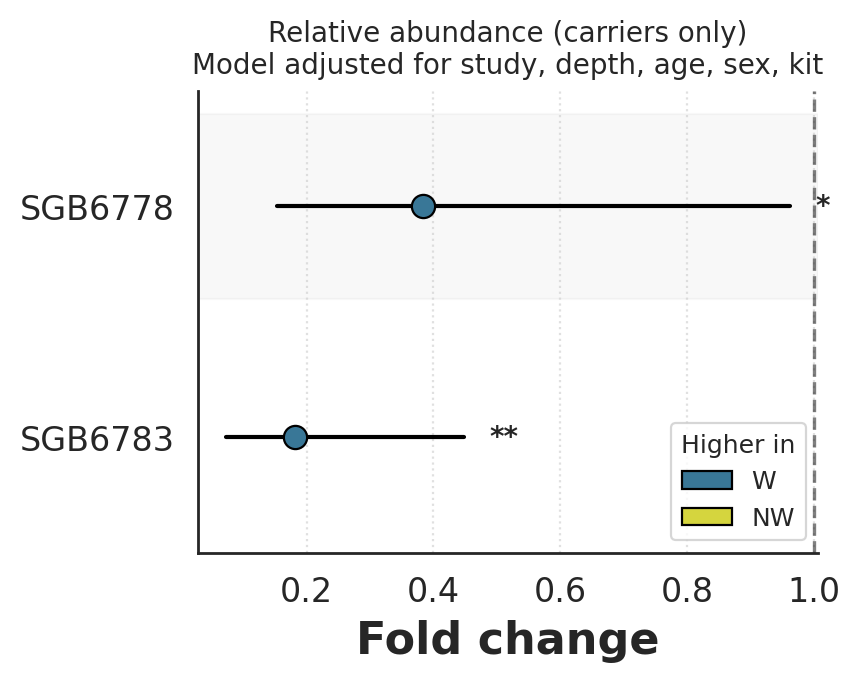

In [8]:
forest = carrier_results.copy()
forest['ci_low'] = np.exp(forest['beta'] - 1.96 * forest['std_err'])
forest['ci_high'] = np.exp(forest['beta'] + 1.96 * forest['std_err'])
forest = forest.loc[['SGB6778', 'SGB6783']]          # published panel order, top to bottom

fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
for y, (name, row) in enumerate(forest.iterrows()):
    if y % 2 == 0:
        ax.axhspan(y - 0.4, y + 0.4, color='gray', alpha=0.05, zorder=0)
    significant = row['p_value'] < ALPHA
    # The model codes non-Westernized relative to Westernized, so a fold change above 1
    # means the species is more abundant in non-Westernized carriers, and below 1 in
    # Westernized ones. Non-significant results stay grey.
    higher_in = 'yes' if row['fold_change'] > 1 else 'no'
    color = LIFESTYLE_COLORS[higher_in] if significant else '#888888'
    ax.plot([row['ci_low'], row['ci_high']], [y, y], color='black', linewidth=1.5, zorder=2)
    ax.scatter(row['fold_change'], y, s=70, color=color,
               edgecolors='black', linewidths=0.8, zorder=3)
    stars = '**' if row['p_value'] < 0.005 else ('*' if significant else 'ns')
    ax.text(row['ci_high'] + 0.04, y, stars, va='center', ha='left',
            fontsize=10, fontweight='bold' if significant else 'normal')

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5, zorder=1)
ax.set_yticks(range(len(forest)))
ax.set_yticklabels(forest.index)
ax.set_ylim(-0.5, len(forest) - 0.5)
ax.invert_yaxis()
ax.set_xlabel('Fold change', fontweight='bold')
ax.set_title('Relative abundance (carriers only)\n'
             'Model adjusted for study, depth, age, sex, kit', fontsize=10)
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.legend(handles=[Patch(facecolor=LIFESTYLE_COLORS[k], edgecolor='black', label=v)
                   for k, v in LIFESTYLE_LABELS.items()],
          title='Higher in', loc='lower right', frameon=True, fontsize=9, title_fontsize=9)
for side in ('left', 'bottom'):
    ax.spines[side].set_visible(True)
plt.show()

## 4. Figures S5c and S5d — ANI

Evaluate ANI distributions between MAGs from Catenibacterium subspecies, computed using SKANI.

In [33]:
with open("../data/cate_skani_ani_matrix.txt", 'r') as f:
    lines = f.readlines()

try:
    num_taxa = int(lines[0].strip())
    data_lines = lines[1:]
except ValueError:
    data_lines = lines

parsed_data = [l.strip().split('\t') for l in data_lines]
indices = [row[0] for row in parsed_data]
values = [row[1:] for row in parsed_data]

ani = pd.DataFrame(values, index=indices)
ani = ani.apply(pd.to_numeric, errors='coerce')

if ani.shape[1] < ani.shape[0]:
    diff = ani.shape[0] - ani.shape[1]
    for i in range(diff):
        ani[f'extra_{i}'] = np.nan

magtable = pd.read_table("../data/MAG_table_filtered.tsv", index_col=0)
rename_genome = dict(zip(magtable.original_name, magtable.index))
rename_genome["CM85Y_71"] = "CM85Y_71"
rename_genome["LM_D1_89"] = "LM_D1_89"
rename_genome["LM_D2_65"] = "LM_D2_65"
rename_genome["M1464052795"] = "DSM15897T"
rename_genome["M1818844748"] = "CMD8551"

ani.index = [rename_genome[i.split("/")[1].split(".fna")[0]] for i in ani.index]
ani.columns = ani.index

genome2sgb = dict(magtable.SGB)
genome2sgb["CM85Y_71"] = "SGB6778_group"
genome2sgb["LM_D1_89"] = "SGB6783"
genome2sgb["LM_D2_65"] = "SGB6783"
genome2sgb["DSM15897T"] = "SGB6778_group"
genome2sgb["CMD8551"] = "SGB6783"

tridentinum_genomes = [i for i in ani.index if genome2sgb[i] == "SGB6783"]
mitsuokai_genomes = [i for i in ani.index if genome2sgb[i] == "SGB6778_group"]

ani_tridentinum = ani.loc[tridentinum_genomes][tridentinum_genomes]
ani_mitsuokai = ani.loc[mitsuokai_genomes][mitsuokai_genomes]

In [35]:
mag_meta = pd.read_table("../data/catenibacterium_mags_meta_full.tsv", index_col=0)
mag_meta.head()

,completeness,contamination,strain_heterogeneity,original_name,release,chunk,sequence_path,annotation_path,SGB,lifestyle,...,country,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
M1002796588,100.000000,0.000000,0.113330,CosteaPI_2017__SID713B003-11-0-0__bin.48,Jan19,123,/shares/CIBIO-Storage/CM/scratch/databases/Met...,/shares/CIBIO-Storage/CM/scratch/databases/Met...,SGB6783,W,...,KAZ,IlluminaHiSeq,29242367.0,70012922.0,6.225547e+09,45.0,92.0,ERR1729149;ERR1729148;ERR1729147;ERR1729146;ER...,Paolo_Manghi;Valentina_Giunchiglia;Marisa_Metzger,Gnome
M1004731136,94.500000,2.830000,33.330000,KaurK_2020__LDK_4__bin.63,Sep20,1,/shares/CIBIO-Storage/CM/scratch/databases/Met...,/shares/CIBIO-Storage/CM/scratch/databases/Met...,SGB6783,NW,...,IND,IlluminaHiSeq,32267865.0,99095190.0,1.336204e+10,1.0,151.0,SRR9108968,Anna_Pedrotti,ZR_Fecal_DNA_MiniPrep
M1006942200,92.075472,1.886792,0.422094,BritoIL_2016__W2.21.ST__bin.15,Jan19,123,/shares/CIBIO-Storage/CM/scratch/databases/Met...,/shares/CIBIO-Storage/CM/scratch/databases/Met...,SGB6783,NW,...,FJI,IlluminaHiSeq,27409808.0,103077574.0,1.041083e+10,101.0,101.0,SRR2222819;SRR2223140;SRR2227739;SRR2227823;SR...,Paolo_Manghi,Qiagen
M1010155839,94.340000,0.940000,0.000000,CM_tanzania__C16-20474-TZ__bin.38,Aug19,0,/shares/CIBIO-Storage/CM/scratch/databases/Met...,/shares/CIBIO-Storage/CM/scratch/databases/Met...,SGB6778_group,NW,...,TZA,IlluminaHiSeq,1.0,35872614.0,3.607055e+09,75.0,101.0,NaN,NaN,Qiagen
M1011210369,100.000000,1.707098,0.017489,BackhedF_2015__SID157_M__bin.37,Jan19,123,/shares/CIBIO-Storage/CM/scratch/databases/Met...,/shares/CIBIO-Storage/CM/scratch/databases/Met...,SGB6783,W,...,SWE,IlluminaHiSeq,25974306.0,42149344.0,4.204923e+09,80.0,100.0,ERR525729,Valentina_Giunchiglia,NaN


In [36]:
ani_df = ani.copy()
meta_df = mag_meta.copy()

meta_df['lifestyle_clean'] = meta_df['lifestyle'].replace({'lab_strain': 'W'})

def classify_pair(l1, l2):
    if pd.isna(l1) or pd.isna(l2):
        return np.nan
    s = sorted([str(l1), str(l2)])
    return 'W-NW' if s == ['NW', 'W'] else f"{s[0]}-{s[1]}"

intra_pairs_list = []

for sgb, sgb_meta in meta_df.groupby('SGB'):
    # Get genomes present in both metadata and ANI matrix for this SGB
    sgb_genomes = sgb_meta.index.intersection(ani_df.index)
    if len(sgb_genomes) < 2:
        continue  # Need at least 2 genomes to form a pair
    
    # Extract sub-matrix for this SGB only
    sub_ani = ani_df.loc[sgb_genomes, sgb_genomes]
    sub_ani_sym = sub_ani.combine_first(sub_ani.T)
    
    # Extract upper triangular unique pairs
    mask = np.triu(np.ones(sub_ani_sym.shape), k=1).astype(bool)
    sub_pairs = sub_ani_sym.where(mask).stack().reset_index()
    sub_pairs.columns = ['Genome1', 'Genome2', 'ANI']
    
    # Add metadata
    sub_pairs['SGB'] = sgb
    l1 = sub_pairs['Genome1'].map(sgb_meta['lifestyle_clean'])
    l2 = sub_pairs['Genome2'].map(sgb_meta['lifestyle_clean'])
    
    sub_pairs['Pair_Type'] = [classify_pair(a, b) for a, b in zip(l1, l2)]
    sub_pairs['Distance'] = 100 - sub_pairs['ANI']
    
    intra_pairs_list.append(sub_pairs)

# Combine all intra-SGB pairs across SGBs
intra_pairs_df = pd.concat(intra_pairs_list, ignore_index=True).dropna(subset=['Pair_Type'])

# Summary statistics per SGB and Lifestyle Pair
intra_stats = intra_pairs_df.groupby(['SGB', 'Pair_Type'])['Distance'].describe()

print(intra_stats)

                           count      mean       std   min   25%    50%  \
SGB           Pair_Type                                                   
SGB6778_group NW-NW       1128.0  1.877757  0.649193  0.05  1.35  1.695   
              W-NW        1776.0  2.358536  0.484792  0.82  2.22  2.510   
              W-W          666.0  1.943003  0.577175  0.05  1.53  1.795   
SGB6783       NW-NW       2016.0  2.224519  0.878313  0.03  1.57  2.180   
              W-NW        9664.0  3.290829  0.574653  1.08  3.15  3.440   
              W-W        11325.0  2.647133  0.740585  0.00  2.23  2.720   

                            75%   max  
SGB           Pair_Type                
SGB6778_group NW-NW      2.5025  3.41  
              W-NW       2.6600  3.51  
              W-W        2.4500  3.31  
SGB6783       NW-NW      2.5825  4.48  
              W-NW       3.6400  4.88  
              W-W        3.1700  4.54  


[None, None]

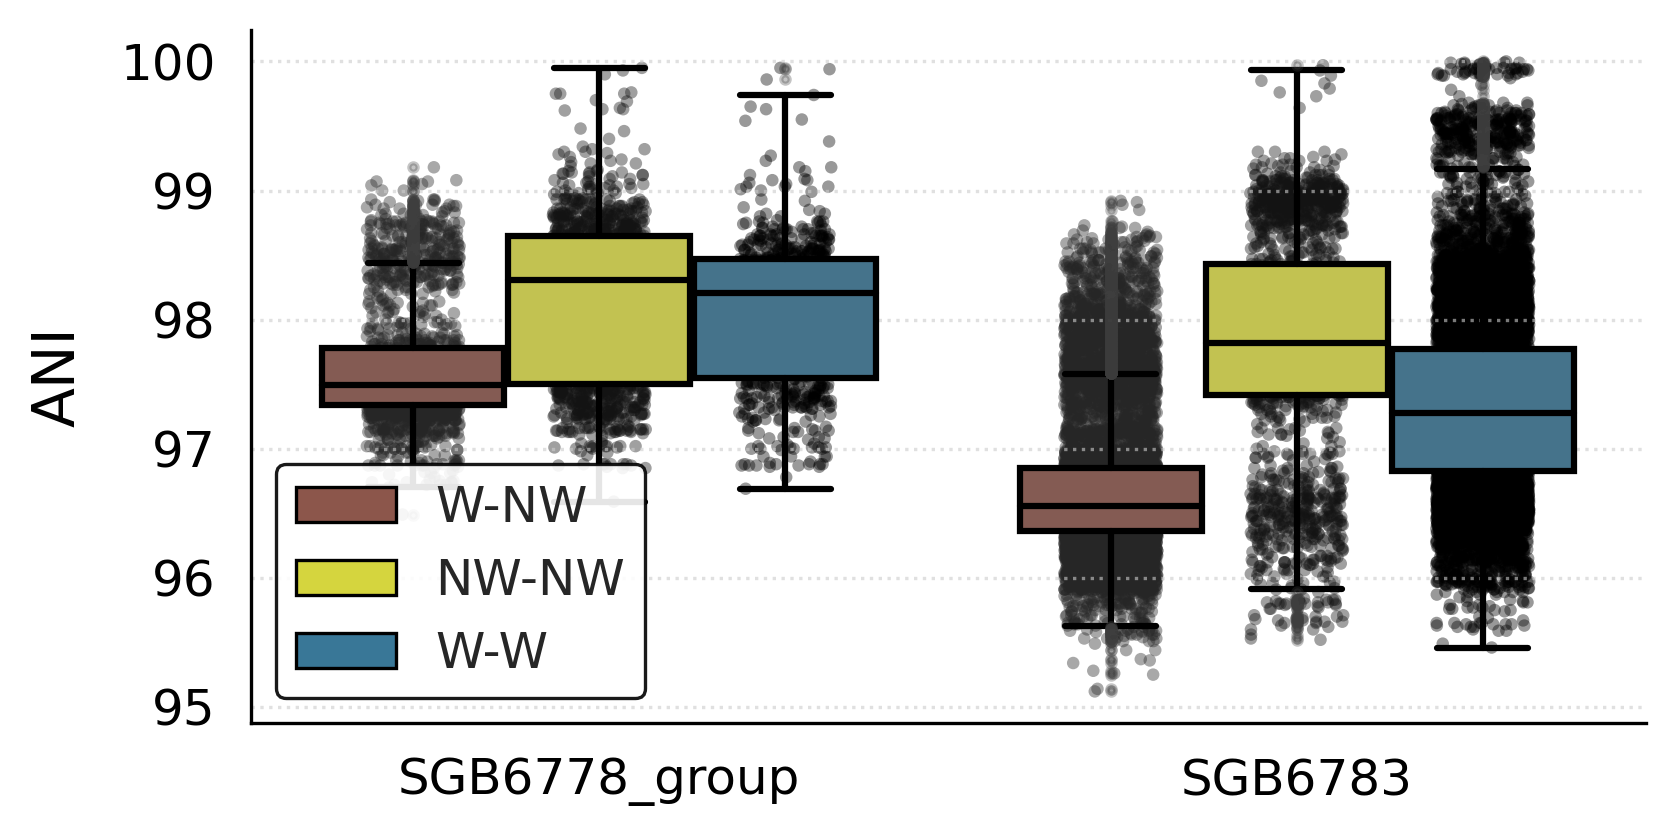

In [39]:
# color definitions
color_w = "#397797"       # Westernized
color_nw = "#d5d53e"      # Non-Westernized
color_cross = "#8c564b"   # Cross-population (W-NW / NW-W)

full_palette_map = {
    "W-W": color_w,
    "W_W": color_w,
    "WW": color_w,
    "NW-NW": color_nw,
    "NW_NW": color_nw,
    "NWN_NW": color_nw,
    "NW-W": color_cross,
    "W-NW": color_cross,
    "NW_W": color_cross,
    "W_NW": color_cross,
    "Cross": color_cross,
    "Inter": color_cross
}

unique_types = intra_pairs_df["Pair_Type"].unique()
pair_palette = {k: full_palette_map[k] for k in unique_types if k in full_palette_map}

fig, ax = plt.subplots(figsize=(6,3), dpi=300)
sns.set_theme(style="whitegrid", font="sans-serif")

sns.boxplot(
    data=intra_pairs_df,
    x="SGB",
    y="ANI",
    hue="Pair_Type",
    palette=pair_palette,
    boxprops=dict(edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax,
    zorder=2
)

sns.stripplot(
    data=intra_pairs_df,
    x="SGB",
    y="ANI",
    hue="Pair_Type",
    dodge=True,
    color="black",
    alpha=0.4,
    size=3,
    jitter=0.2,
    ax=ax,
    zorder=0,
    rasterized=True
)

ax.set_xlabel("")
ax.set_ylabel("ANI", fontsize=14, fontweight="medium", labelpad=8, color="black")

ax.tick_params(axis='both', which='major', labelsize=12, colors='black', width=0.8)

ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(0.8)

ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.grid(axis='x', visible=False)

legend_handles = [
    mpatches.Patch(facecolor=pair_palette[k], edgecolor='black', linewidth=0.8, label=k)
    for k in unique_types if k in pair_palette
]

legend = ax.legend(
    handles=legend_handles,

    loc="lower left",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=12
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.8)
plt.setp(legend.get_title(), color="black")

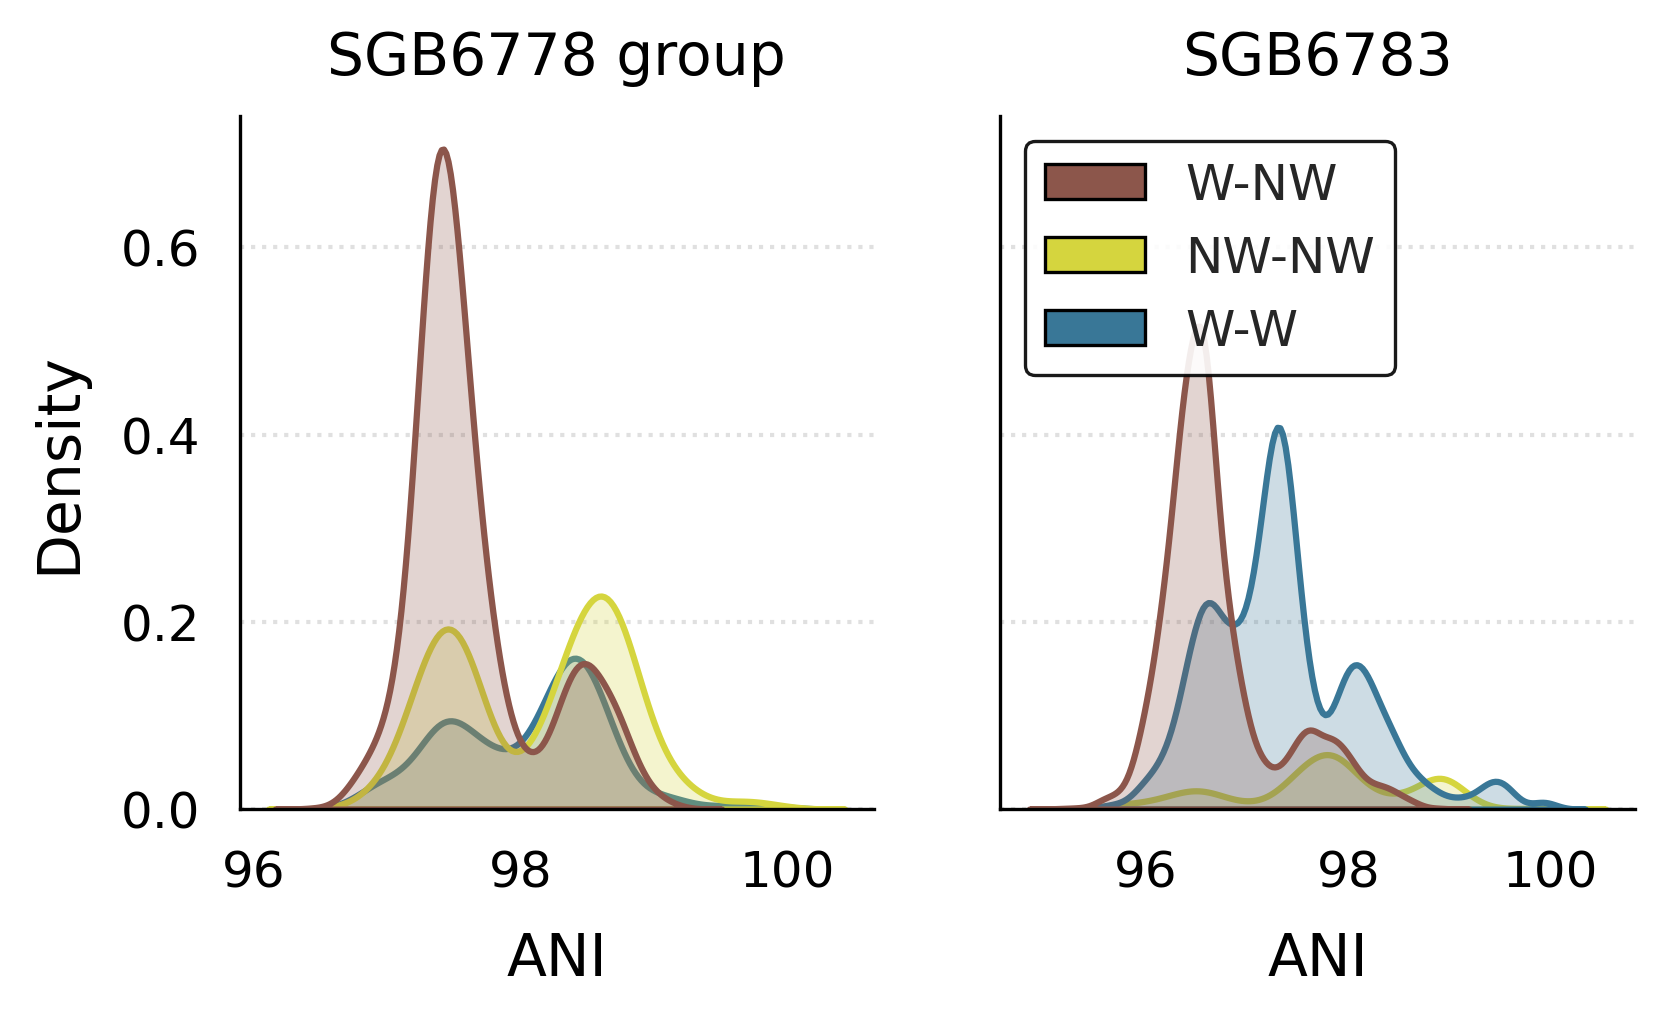

In [40]:
fig, axes = plt.subplots(figsize=(6,3), ncols=2, dpi=300, sharey=True)
sns.set_theme(style="whitegrid", font="sans-serif")

sgbs = ["SGB6778_group", "SGB6783"]
titles = ["SGB6778 group", "SGB6783"]

for ax, sgb_id, title in zip(axes, sgbs, titles):
    sub_df = intra_pairs_df[intra_pairs_df.SGB == sgb_id]

    sns.kdeplot(
        data=sub_df,
        x="ANI",
        hue="Pair_Type",
        palette=pair_palette,
        linewidth=1.5,
        fill=True,
        alpha=0.25,
        ax=ax,
        zorder=2
    )
    
    ax.set_title(title, fontsize=14, fontweight="medium", color="black", pad=10)
    ax.set_xlabel("ANI", fontsize=14, fontweight="medium", labelpad=8, color="black")
    
    ax.tick_params(axis='both', which='major', labelsize=12, colors='black', width=0.8)
    
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(0.8)
    
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(0.8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax.grid(False, axis='x')

axes[0].set_ylabel("Density", fontsize=14, fontweight="medium", labelpad=8, color="black")

legend_handles = [
    mpatches.Patch(facecolor=pair_palette[k], edgecolor='black', linewidth=0.8, label=k)
    for k in unique_types if k in pair_palette
]

legend = axes[1].legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=12
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.8)
plt.setp(legend.get_title(), color="black")

for ax in axes:
    if ax.get_legend() and ax.get_legend() != legend:
        ax.get_legend().remove()

## 5. Figure S5e — *Catenibacterium* phylogeny

The tree is rooted on the longest internal branch and ladderised, then an annotation file is written for GraPhlAn, which renders the circular figure outside this notebook.

The input `cleaned.rooted.tre` is itself derived from the RAxML tree by a cleaning step that is not part of the original notebook, so the first cell below only renames the RAxML leaves from genome names to MAG identifiers and checks that the two trees carry the same leaves.

In [12]:
magtable = pd.read_table(MAG_TABLE, index_col=0)
mag_metadata = pd.read_table(MAG_METADATA, index_col=0)

LAB_STRAINS = {'LM2_D2_65': 'SGB6783', 'LM2_D1_89': 'SGB6783', 'CM85Y_71': 'SGB6778_group'}

name2mag = dict(zip(magtable['original_name'], magtable.index))
raxml = Phylo.read(f'{TREE_DIR}/RAxML_bestTree.input_genomes_refined.tre', 'newick')
for leaf in raxml.get_terminals():
    leaf.name = name2mag.get(leaf.name, leaf.name)
Phylo.write(raxml, f'{TREE_DIR}/RAxML_bestTree.renamed.tre', 'newick')

cleaned = Phylo.read(f'{TREE_DIR}/cleaned.rooted.tre', 'newick')
only_in_raxml = {leaf.name for leaf in raxml.get_terminals()} - {leaf.name for leaf in cleaned.get_terminals()}
print(f'{len(only_in_raxml)} leaves in the RAxML tree are absent from cleaned.rooted.tre')

2 leaves in the RAxML tree are absent from cleaned.rooted.tre


In [13]:
# Root on the longest internal branch, then ladderise so the drawing order is reproducible.
tree = Phylo.read(f'{TREE_DIR}/cleaned.rooted.tre', 'newick')
longest_internal = max((c for c in tree.get_nonterminals() if c.branch_length is not None),
                       key=lambda c: c.branch_length)
tree.root_with_outgroup(longest_internal)
tree.ladderize(reverse=False)

rerooted_path = f'{TREE_DIR}/rerooted_longest_internal.tre'
Phylo.write(tree, rerooted_path, 'newick')
leaves = [leaf.name for leaf in tree.get_terminals()]
print(f'{len(leaves)} genomes in the tree')

305 genomes in the tree


In [ ]:
COUNTRY_COLORS = {
    'FJI': '#1f77b4', 'ISR': '#ff7f0e', 'KAZ': '#2ca02c', 'IRL': '#d62728', 'TZA': '#9467bd',
    'DNK': '#8c564b', 'GBR': '#e377c2', 'IND': '#17becf', 'NLD': '#bcbd22', 'PER': '#393b79',
    'MNG': '#637939', 'SWE': '#8c6d31', 'ESP': '#843c39', 'CHN': '#7b4173', 'ARG': '#3182bd',
    'AUT': '#e6550d', 'USA': '#31a354', 'GNB': '#756bb1', 'FRA': '#e7ba52', 'GHA': '#ad494a',
    'CMR': '#a55194', 'ETH': '#6b6ecf', 'COL': '#b5cf6b', 'BGD': '#cedb9c', 'RUS': '#9c9ede',
    'MDG': '#fdae6b', 'EST': '#fd8d3c', 'DEU': '#e41a1c',
}

STUDY_COLORS = {
    'BritoIL_2016': '#e6194b', 'ZeeviD_2015': '#3cb44b', 'CosteaPI_2017': '#ffe119',
    'KeohaneDM_2020': '#4363d8', 'CM_tanzania_TB_DAR': '#f58231', 'KaurK_2020': '#911eb4',
    'LeChatelierE_2013': '#46f0f0', 'SchirmerM_2016': '#f032e6', 'ShaoY_2019': '#bcf60c',
    'HansenLBS_2018': '#fabebe', 'XieH_2016': '#008080', 'LiuW_2016': '#e6beff',
    'Obregon-TitoAJ_2015': '#9a6324', 'NielsenHB_2014': '#fffac8', 'CM_argentina': '#800000',
    'KarlssonFH_2013': '#aaffc3', 'BackhedF_2015': '#808000', 'FengQ_2015': '#ffd8b1',
    'ThomasAM_2019': '#000075', 'CM_tanzania': '#ff4500', 'CM_ghana': '#2e8b57',
    'ZellerG_2014': '#1e90ff', 'QinJ_2012': '#ff1493', 'LokmerA_2019': '#00ced1',
    'CM_guinea2': '#ff8c00', 'JieZ_2017': '#9932cc', 'VatanenT_2016': '#20b2aa',
    'CM_ethiopia': '#ff6347', 'QinN_2014': '#7fff00', 'CM_colombia': '#dc143c',
    'LiJ_2014': '#00fa9a', 'CM_tanzania2': '#8a2be2', 'KieserS_2018': '#ff69b4',
    'DhakanDB_2019': '#cd5c5c', 'CM_guinea': '#4b0082', 'HMP_2012': '#adff2f',
    'GCA_025148785': '#CCD1D1', 'IjazUZ_2017': '#228b22', 'LiSS_2016': '#b22222',
    'MehtaRS_2018': '#5f9ea0', 'CM_madagascar': '#daa520', 'Bengtsson-PalmeJ_2015': '#7b68ee',
    'WirbelJ_2018': '#ffdead', 'VogtmannE_2016': '#40e0d0', 'PehrssonE_2016': '#ff7f50',
    'GCA_029675045.1': '#CCD1D1',
}

GREY = '#CCD1D1'
TREE_COLORS = {'W': '#397797', 'NW': '#d5d53e', 'SGB6783': '#F1948A', 'SGB6778_group': '#85C1E9'}
ISOLATE_COLOR = '#FF5722'


def genome_attributes(genome):
    """Marker and ring colours for one leaf of the tree."""
    is_lab_strain = genome in LAB_STRAINS or magtable['lifestyle'].get(genome) == 'lab_strain'
    sgb = LAB_STRAINS.get(genome, magtable['SGB'].get(genome))
    lifestyle = magtable['lifestyle'].get(genome)
    return {
        'marker_color': ISOLATE_COLOR if is_lab_strain else '#D4D4D4',
        'marker_shape': '*' if is_lab_strain else 'o',
        'is_lab_strain': is_lab_strain,
        'lifestyle': TREE_COLORS.get(lifestyle, GREY),
        'species': TREE_COLORS.get(sgb, GREY),
        'country': COUNTRY_COLORS.get(mag_metadata['country'].get(genome), GREY),
        'study': STUDY_COLORS.get(mag_metadata['study_name'].get(genome), GREY),
    }


def graphlan_annotation(genomes, rings=('lifestyle', 'species', 'country', 'study')):
    """GraPhlAn annotation file: one coloured marker per genome plus one ring per variable."""
    lines = [
        'title\tcombined', 'total_plotted_degrees\t350', 'start_rotation\t90',
        'class_legend_font_size\t10', 'annotation_background_separation\t0.03',
        'annotation_background_width\t0.0', 'annotation_font_size\t11',
        'clade_marker_size\t0', 'branch_thickness\t2', 'branch_bracket_width\t0.0',
        'clade_marker_edge_width\t1',
    ]
    for index, name in enumerate(rings, start=1):
        lines += [f'ring_label\t{index}\t{name.capitalize()}',
                  f'ring_internal_separator_thickness\t{index}\t1',
                  f'ring_external_separator_thickness\t{index}\t1',
                  f'ring_separator_color\t{index}\tk']

    # Legend entries: one dummy clade per category value.
    legend = {'SGB6783': ('o', TREE_COLORS['SGB6783']), 'SGB6778_group': ('o', TREE_COLORS['SGB6778_group']),
              'W': ('s', TREE_COLORS['W']), 'NW': ('s', TREE_COLORS['NW'])}
    legend.update({country: ('s', color) for country, color in COUNTRY_COLORS.items()})
    legend.update({study: ('s', color) for study, color in STUDY_COLORS.items()})
    for label, (shape, color) in legend.items():
        lines += [f'{label}\tclade_marker_shape\t{shape}',
                  f'{label}\tclade_marker_size\t100',
                  f'{label}\tclade_marker_color\t{color}']

    for genome in genomes:
        attributes = genome_attributes(genome)
        lines.append(f'{genome}\tclade_marker_color\t{attributes["marker_color"]}')
        if attributes['is_lab_strain']:
            lines += [f'{genome}\tclade_marker_size\t250',
                      f'{genome}\tclade_marker_label\t{genome}',
                      f'{genome}\tclade_marker_font_size\t14',
                      f'{genome}\tclade_marker_font_color\tk']
        else:
            lines.append(f'{genome}\tclade_marker_size\t50')
        lines.append(f'{genome}\tclade_marker_shape\t{attributes["marker_shape"]}')
        for index, name in enumerate(rings, start=1):
            lines += [f'{genome}\tring_color\t{index}\t{attributes[name]}',
                      f'{genome}\tring_width\t{index}\t1',
                      f'{genome}\tring_height\t{index}\t0.5']
    return '\n'.join(lines) + '\n'


with open(ANNOTATION_OUT, 'w') as handle:
    handle.write(graphlan_annotation(leaves))
print(f'annotation for {len(leaves)} genomes written to {ANNOTATION_OUT}')

The figure itself is drawn by GraPhlAn from the tree and the annotation file. Run this outside the notebook, in an environment with GraPhlAn installed, and confirm the options against the ones used for the manuscript:

```bash
graphlan_annotate.py --annot phylo_annot_rerooted_longest_internal.txt \
                     rerooted_longest_internal.tre catenibacterium.xml
graphlan.py --dpi 300 --size 10 catenibacterium.xml FigureS5e.svg
```

The isolate labels (`CM58Y`, `CM85Y_71`, `LM2_D2_65`, `LM2_D1_89`, `CMD8551T`) and the legend in the published panel were placed by hand afterwards.

## 6. Figure S6 — glycan utilisation

Growth is measured as ODmax − ODi for each strain on each glycan, across replicates and experimental batches. Each strain gets one linear model in a randomised block design: growth against glycan, with the basal medium as reference level and the batch as a block. Within each strain the p-values are Holm-corrected.

In [28]:
BASAL = "Y basal (-)"
ALPHA = 0.05

# Load data
df = pd.read_csv("../data/catenibacterium_glycans.tsv", sep="\t")
df["experiment"] = df["experiment"].astype(str)  # treat batch id as categorical

# lookup table glycan abbreviation
name_map = (
    df[["glycan_name_abbrev", "glycan_name_full"]]
    .drop_duplicates()
    .set_index("glycan_name_abbrev")["glycan_name_full"]
    .to_dict()
)

# Randomized-block-design model, one per strain, glycan vs. basal adjusted for batch
rows = []
diagnostics = {}

for strain, sub in df.groupby("strain"):
    sub = sub.copy()
    cats = [BASAL] + sorted(c for c in sub["glycan_name_abbrev"].unique() if c != BASAL)
    sub["glycan_name_abbrev"] = pd.Categorical(sub["glycan_name_abbrev"], categories=cats)

    formula = (
        f'odmax_odi ~ C(glycan_name_abbrev, Treatment(reference="{BASAL}")) '
        f"+ C(experiment)"
    )
    model = smf.ols(formula, data=sub).fit()
    diagnostics[strain] = model  # keep for residual checks below

    params, pvals, conf = model.params, model.pvalues, model.conf_int()
    for name in params.index:
        if not name.startswith("C(glycan_name_abbrev"):
            continue  # skip intercept and batch/block dummies
        glycan = name.split("T.")[-1].rstrip("]")
        n_reps = (sub["glycan_name_abbrev"] == glycan).sum()
        rows.append(
            {
                "strain": strain,
                "glycan": glycan,
                "glycan_full": name_map.get(glycan, glycan),
                "n_replicates": n_reps,
                "effect_vs_basal": params[name],   # OD units, batch-adjusted
                "ci_low": conf.loc[name, 0],
                "ci_high": conf.loc[name, 1],
                "p_raw": pvals[name],
            }
        )

results = pd.DataFrame(rows)
results["p_holm"] = results.groupby("strain")["p_raw"].transform(
    lambda p: multipletests(p, method="holm")[1]
)
results["significant"] = results["p_holm"] < ALPHA
results = results.sort_values(["strain", "effect_vs_basal"], ascending=[True, False])
results.to_csv("glycan_vs_basal_results.csv", index=False)


# Residual diagnostics (sanity-check model assumptions)
print("\n=== Residual diagnostics per strain (Shapiro-Wilk normality test) ===")
from scipy import stats as spstats

for strain, model in diagnostics.items():
    resid = model.resid
    w, p = spstats.shapiro(resid)
    print(f"{strain}: Shapiro-Wilk W={w:.3f}, p={p:.3f} "
          f"({'no strong evidence against normality' if p > 0.05 else 'residuals deviate from normal - interpret p-values cautiously'})")

# Descriptive, batch-matched normalization (for plotting only)
#    - net OD  = glycan_OD - mean(basal OD in same strain+batch)
#    - fold    = glycan_OD / mean(basal OD in same strain+batch)
#    Batches with no basal replicate (tride/experiment 5) fall back to
#    that strain's pooled basal mean across its other batches, and are
#    flagged.
basal_by_batch = (
    df[df["glycan_name_abbrev"] == BASAL]
    .groupby(["strain", "experiment"])["odmax_odi"]
    .mean()
    .rename("basal_batch_mean")
)
basal_by_strain = (
    df[df["glycan_name_abbrev"] == BASAL]
    .groupby("strain")["odmax_odi"]
    .mean()
    .rename("basal_strain_mean")
)

norm = df.merge(basal_by_batch, on=["strain", "experiment"], how="left")
norm = norm.merge(basal_by_strain, on="strain", how="left")
norm["basal_used"] = norm["basal_batch_mean"].fillna(norm["basal_strain_mean"])
norm["basal_imputed"] = norm["basal_batch_mean"].isna()
norm["net_od"] = norm["odmax_odi"] - norm["basal_used"]
norm["fold_change"] = norm["odmax_odi"] / norm["basal_used"]
norm.to_csv("glycan_normalized_descriptive.csv", index=False)

if norm["basal_imputed"].any():
    n_imp = norm.loc[norm["basal_imputed"], ["strain", "experiment"]].drop_duplicates()
    print(f"\nNote: batch(es) with no basal replicate, so strain-level pooled "
          f"basal mean was used instead for the descriptive net_od/fold_change "
          f"columns only (NOT for the model-based p-values above):")
    print(n_imp.to_string(index=False))

results.to_csv("../data/cate_rbd_lm_glycans.tsv", index=False, sep="\t")


=== Residual diagnostics per strain (Shapiro-Wilk normality test) ===
mitsuo_T: Shapiro-Wilk W=0.920, p=0.000 (residuals deviate from normal - interpret p-values cautiously)
mitsuo_isolate: Shapiro-Wilk W=0.915, p=0.000 (residuals deviate from normal - interpret p-values cautiously)
tride: Shapiro-Wilk W=0.989, p=0.219 (no strong evidence against normality)

Note: batch(es) with no basal replicate, so strain-level pooled basal mean was used instead for the descriptive net_od/fold_change columns only (NOT for the model-based p-values above):
strain experiment
 tride          5


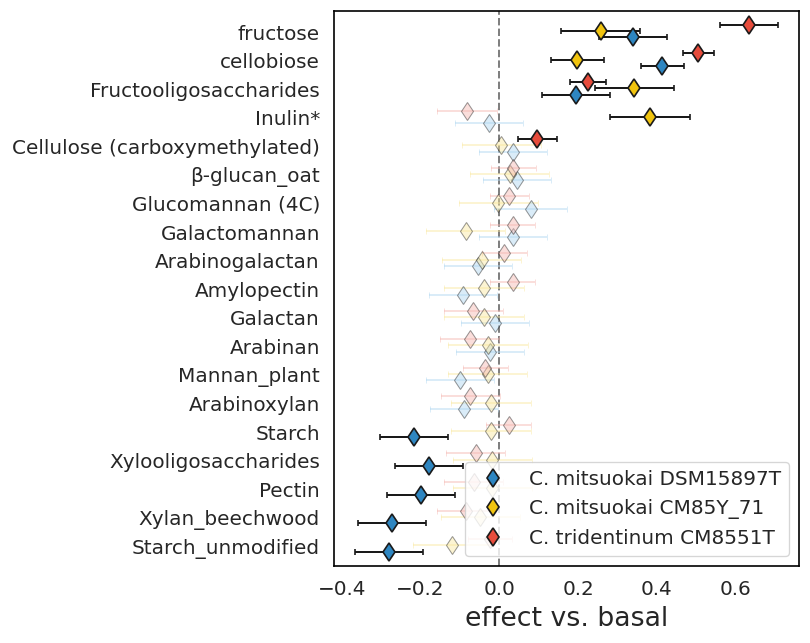

In [29]:
strain2name = {
    'mitsuo_T':'C. mitsuokai DSM15897T',
    'mitsuo_isolate':'C. mitsuokai CM85Y_71',
    'tride':'C. tridentinum CM8551T'
}

df = pd.read_csv('../data/cate_rbd_lm_glycans.tsv', sep='\t')
df["strain"] = df["strain"].map(strain2name)

strains = ['C. mitsuokai DSM15897T', 'C. mitsuokai CM85Y_71', 'C. tridentinum CM8551T']

# order glycans by mean effect across strains (descending), like a typical forest plot
order = (df.groupby('glycan_full')['effect_vs_basal']
           .mean().sort_values(ascending=False).index.tolist())

n = len(order)
y_pos = np.arange(n)

# offsets so the 3 strains stack under each other within each glycan row
offsets = {strains[0]: 0.22, strains[1]: 0.0, strains[2]: -0.22}

# base (faint) pastel colors -- same family as the reference plot
faint_colors = {
    'C. mitsuokai DSM15897T':       "#AED6F1",  # light blue
    'C. mitsuokai CM85Y_71': "#F9E79F",  # light yellow
    'C. tridentinum CM8551T':          "#F5B7B1",  # light pink/red
}
# saturated (popping) versions of the same hues, for significant points
pop_colors = {
    'C. mitsuokai DSM15897T':       "#2E86C1",  # strong blue
    'C. mitsuokai CM85Y_71': "#F1C40F",  # strong gold
    'C. tridentinum CM8551T':          "#E74C3C",  # strong red
}

fig, ax = plt.subplots(figsize=(5,6))

for strain in strains:
    sub = df[df['strain'] == strain].set_index('glycan_full').reindex(order)
    y = y_pos + offsets[strain]

    x = sub['effect_vs_basal'].values
    lo = (sub['effect_vs_basal'] - sub['ci_low']).values
    hi = (sub['ci_high'] - sub['effect_vs_basal']).values
    sig = sub['significant'].values

    # non-significant: faint pastel, low alpha
    mask_ns = ~sig
    if mask_ns.any():
        ax.errorbar(
            x=x[mask_ns], y=y[mask_ns], xerr=[lo[mask_ns], hi[mask_ns]],
            fmt='d', markersize=8,
            markerfacecolor=faint_colors[strain], alpha=0.45,
            ecolor=faint_colors[strain], capsize=2,
            mec='k', mew=0.6,
        )

    # significant: saturated, fully opaque, pops out
    mask_s = sig
    if mask_s.any():
        ax.errorbar(
            x=x[mask_s], y=y[mask_s], xerr=[lo[mask_s], hi[mask_s]],
            fmt='d', markersize=8,
            markerfacecolor=pop_colors[strain], alpha=1.0,
            ecolor='k', capsize=2,
            mec='k', mew=1.0,
        )

    # one dummy handle per strain for a clean legend (using the pop color)
    ax.errorbar([], [], fmt='d', markersize=8, markerfacecolor=pop_colors[strain],
                mec='k', mew=1.0, ecolor='k', label=strain)

ax.axvline(0, ls='--', color='gray', zorder=0)
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_ylim(-0.7, n - 1 + 0.7)
ax.invert_yaxis()
ax.set_xlabel('effect vs. basal')
ax.legend(frameon=True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)
